<a href="https://colab.research.google.com/github/sudishaG/multi-axis-graphs/blob/main/CQuERE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt

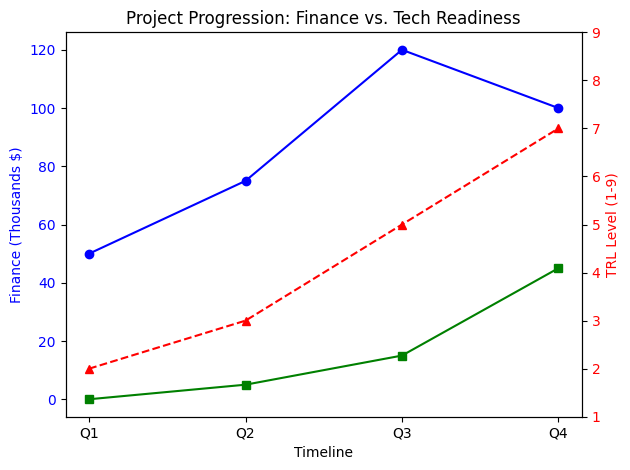

In [2]:
# Data
time = ['Q1', 'Q2', 'Q3', 'Q4']
inv = [50, 75, 120, 100]
rev = [0, 5, 15, 45]
trl = [2, 3, 5, 7]

fig, ax1 = plt.subplots()

# Left Axis: Investment and Revenue
ax1.set_xlabel('Timeline')
ax1.set_ylabel('Finance (Thousands $)', color='blue')
ax1.plot(time, inv, label='Investment', color='blue', marker='o')
ax1.plot(time, rev, label='Revenue', color='green', marker='s')
ax1.tick_params(axis='y', labelcolor='blue')

# Right Axis: TRL Level
ax2 = ax1.twinx()  # Create the second axis
ax2.set_ylabel('TRL Level (1-9)', color='red')
ax2.plot(time, trl, label='TRL Level', color='red', linestyle='--', marker='^')
ax2.set_ylim(1, 9)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Project Progression: Finance vs. Tech Readiness')
fig.tight_layout()
plt.show()

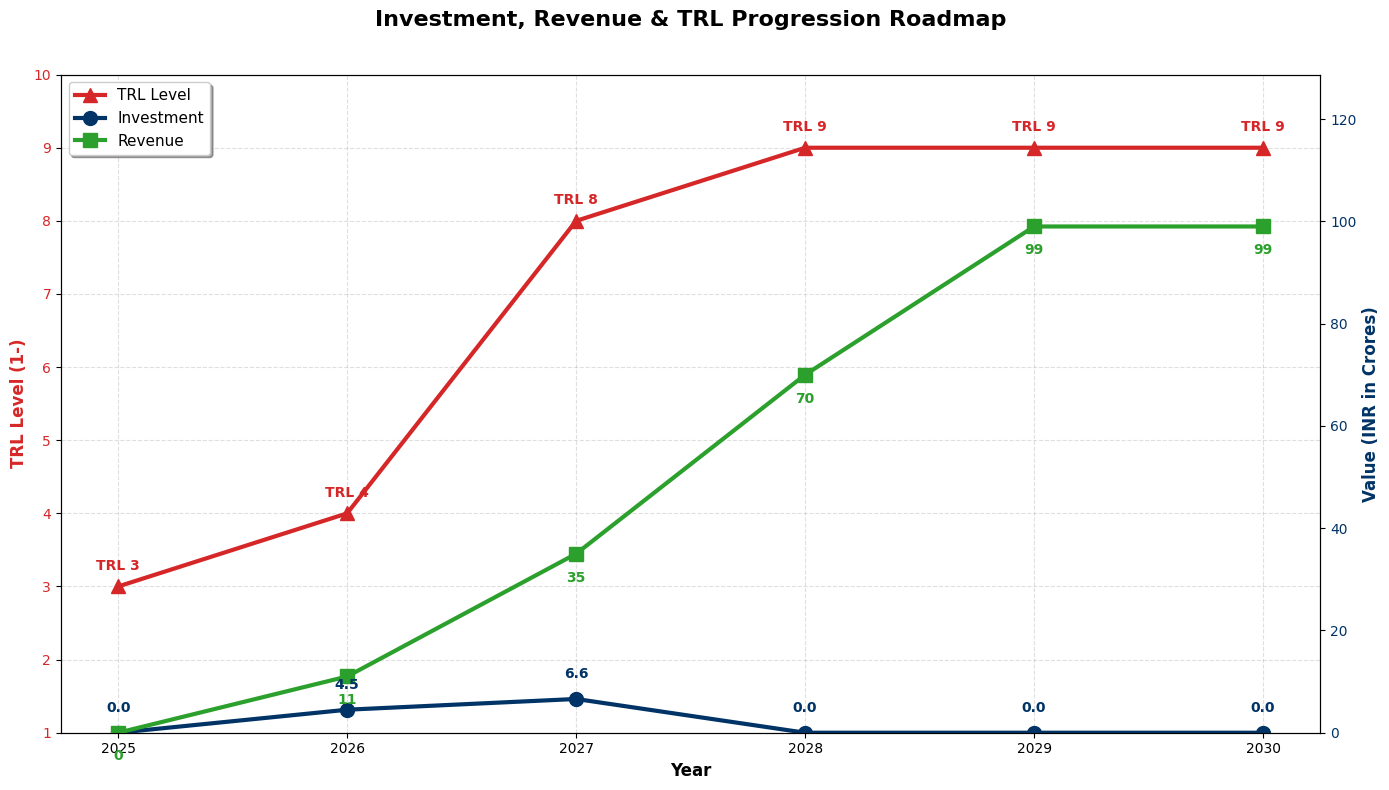

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURATION & DATA LOADING ---
file_name = 'cqueredata.xlsx'

if os.path.exists(file_name):
    df = pd.read_excel(file_name)

    # Ensure Year is integer to avoid .5 intervals and decimal labels
    df['Year'] = df['Year'].astype(int)

    fig, ax1 = plt.subplots(figsize=(14, 8))

    # --- 2. LEFT Y-AXIS: TRL Levels ---
    ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax1.set_ylabel('TRL Level (1-)', color='tab:red', fontsize=12, fontweight='bold')

    # Force X-axis ticks to be only the years in the data
    ax1.set_xticks(df['Year'])

    # TRL Slope (Solid Red)
    line1, = ax1.plot(df['Year'], df['TRL_Level'], color='tab:red', marker='^',
                      linewidth=3, markersize=10, label='TRL Level')

    # Labeling TRL Points (e.g., "TRL 4")
    for i, txt in enumerate(df['TRL_Level']):
        ax1.annotate(f'TRL {txt}', (df['Year'].iat[i], df['TRL_Level'].iat[i]),
                     textcoords="offset points", xytext=(0,12), ha='center',
                     color='tab:red', fontweight='bold', fontsize=10)

    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_ylim(1, 10)
    ax1.set_yticks(range(1, 11))

    # --- 3. RIGHT Y-AXIS: INR in Crores ---
    ax2 = ax1.twinx()
    # Label axis once here, so we don't need "Cr" on every point
    ax2.set_ylabel('Value (INR in Crores)', color='#003366', fontsize=12, fontweight='bold')

    # Investment Slope (Solid Navy Blue)
    line2, = ax2.plot(df['Year'], df['Investment_INR_Cr'], color='#003366',
                      linestyle='-', marker='o', linewidth=3, markersize=10, label='Investment')

    # Revenue Slope (Solid Green)
    line3, = ax2.plot(df['Year'], df['Revenue_INR_Cr'], color='tab:green',
                      marker='s', linewidth=3, markersize=10, label='Revenue')

    # Labeling Financial Points (Numbers only)
    for i in range(len(df)):
        # Label Investment (Above point)
        ax2.annotate(f'{df["Investment_INR_Cr"].iat[i]}',
                     (df['Year'].iat[i], df['Investment_INR_Cr'].iat[i]),
                     textcoords="offset points", xytext=(0,15), ha='center',
                     color='#003366', fontsize=10, fontweight='bold')

        # Label Revenue (Below point)
        ax2.annotate(f'{df["Revenue_INR_Cr"].iat[i]}',
                     (df['Year'].iat[i], df['Revenue_INR_Cr'].iat[i]),
                     textcoords="offset points", xytext=(0,-20), ha='center',
                     color='tab:green', fontsize=10, fontweight='bold')

    ax2.tick_params(axis='y', labelcolor='#003366')

    # Adjust Y-limit to provide space for labels
    max_fin = max(df['Investment_INR_Cr'].max(), df['Revenue_INR_Cr'].max())
    ax2.set_ylim(0, max_fin * 1.3)

    # --- 4. FINAL FORMATTING ---
    plt.title('Investment, Revenue & TRL Progression Roadmap', fontsize=16, pad=35, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.4)

    # Combine legends
    lines = [line1, line2, line3]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True, fontsize=11)

    plt.tight_layout()
    plt.show()

else:
    print(f"❌ Error: {file_name} not found. Please ensure it is uploaded to the Colab sidebar.")